In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score,
    roc_curve
)

In [4]:
df = pd.read_csv("HR_Attrition.csv")

In [5]:
df.head(10)

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2
5,32,No,Travel_Frequently,1005,Research & Development,2,2,Life Sciences,1,8,...,3,80,0,8,2,2,7,7,3,6
6,59,No,Travel_Rarely,1324,Research & Development,3,3,Medical,1,10,...,1,80,3,12,3,2,1,0,0,0
7,30,No,Travel_Rarely,1358,Research & Development,24,1,Life Sciences,1,11,...,2,80,1,1,2,3,1,0,0,0
8,38,No,Travel_Frequently,216,Research & Development,23,3,Life Sciences,1,12,...,2,80,0,10,2,3,9,7,1,8
9,36,No,Travel_Rarely,1299,Research & Development,27,3,Medical,1,13,...,2,80,2,17,3,2,7,7,7,7


In [6]:
print("Rows and Columns:", df.shape)

Rows and Columns: (1470, 35)


In [7]:
df.columns

Index(['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department',
       'DistanceFromHome', 'Education', 'EducationField', 'EmployeeCount',
       'EmployeeNumber', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate',
       'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction',
       'MaritalStatus', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked',
       'Over18', 'OverTime', 'PercentSalaryHike', 'PerformanceRating',
       'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel',
       'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance',
       'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion',
       'YearsWithCurrManager'],
      dtype='object')

In [9]:
print(df["Attrition"].value_counts())

Attrition
No     1233
Yes     237
Name: count, dtype: int64


In [10]:
attrition_rate = (df["Attrition"] == "Yes").mean() * 100

In [11]:
print(f"Attrition Rate: {attrition_rate:.2f}%")

Attrition Rate: 16.12%


In [12]:
from pandas.core.arrays import categorical
numeric = df.select_dtypes(include=np.number)
categorical = df.select_dtypes(include="object")


In [13]:
print("Numeric Columns:", numeric.shape[1])
print("Categorical Columns:", categorical.shape[1])

Numeric Columns: 26
Categorical Columns: 9


In [14]:
df.isnull().sum()

,0
Age,0
Attrition,0
BusinessTravel,0
DailyRate,0
Department,0
DistanceFromHome,0
Education,0
EducationField,0
EmployeeCount,0
EmployeeNumber,0


In [15]:
df.drop(columns=[
    "EmployeeNumber",
    "EmployeeCount",
    "Over18",
    "StandardHours"
], inplace=True)
print(df.shape)

(1470, 31)


In [16]:
df["Attrition"] = df["Attrition"].map({
    "Yes": 1,
    "No": 0
})
df["Attrition"].head()

,Attrition
0,1
1,0
2,1
3,0
4,0


In [17]:
df = pd.get_dummies(df, drop_first=True)
df.head()

,Age,Attrition,DailyRate,DistanceFromHome,Education,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,JobSatisfaction,...,JobRole_Laboratory Technician,JobRole_Manager,JobRole_Manufacturing Director,JobRole_Research Director,JobRole_Research Scientist,JobRole_Sales Executive,JobRole_Sales Representative,MaritalStatus_Married,MaritalStatus_Single,OverTime_Yes
0,41,1,1102,1,2,2,94,3,2,4,...,False,False,False,False,False,True,False,False,True,True
1,49,0,279,8,1,3,61,2,2,2,...,False,False,False,False,True,False,False,True,False,False
2,37,1,1373,2,2,4,92,2,1,3,...,True,False,False,False,False,False,False,False,True,True
3,33,0,1392,3,4,4,56,3,1,3,...,False,False,False,False,True,False,False,True,False,True
4,27,0,591,2,1,1,40,3,1,2,...,True,False,False,False,False,False,False,True,False,False


In [18]:
X = df.drop("Attrition", axis=1)
y = df["Attrition"]

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (1470, 44)
Target shape: (1470,)


In [19]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Data scaling completed.")

Data scaling completed.


In [20]:
eda_df = pd.read_csv("HR_Attrition.csv")
eda_df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


In [21]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.style.use("ggplot")

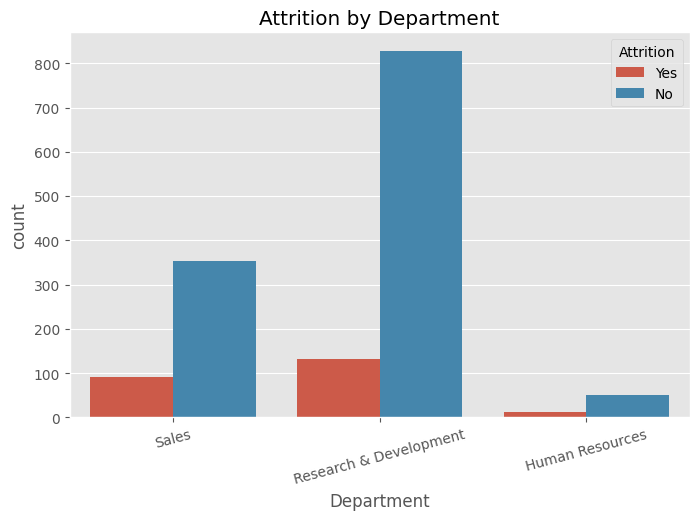

In [22]:
plt.figure(figsize=(8,5))
sns.countplot(
    data=eda_df,
    x="Department",
    hue="Attrition"
)
plt.title("Attrition by Department")
plt.xticks(rotation=15)
plt.savefig("Department_Attrition.png", dpi=300, bbox_inches="tight")
plt.show()

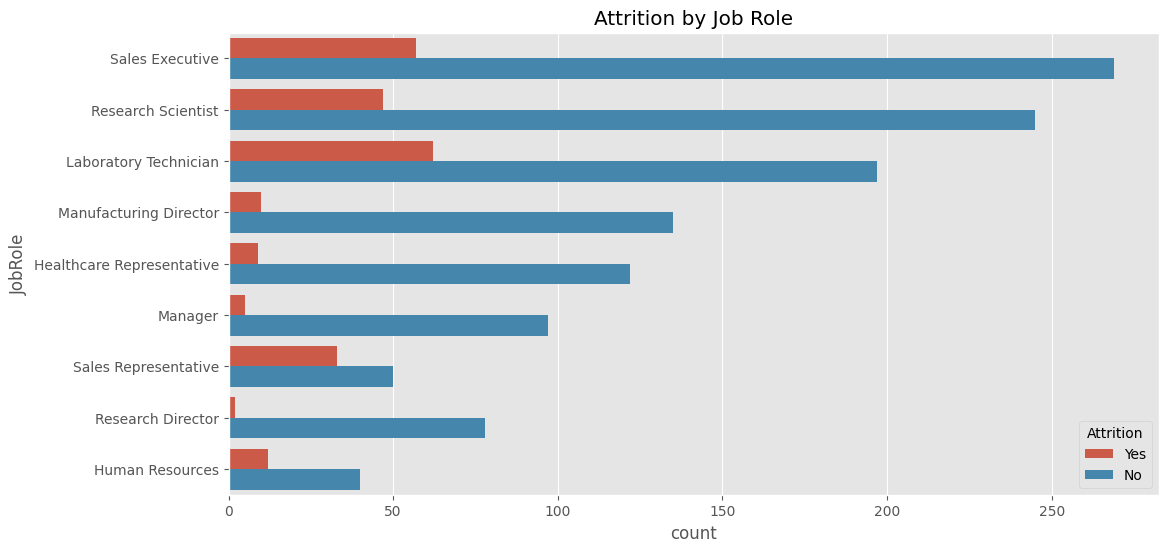

In [23]:
plt.figure(figsize=(12,6))
sns.countplot(
    data=eda_df,
    y="JobRole",
    hue="Attrition"
)
plt.title("Attrition by Job Role")
plt.savefig("JobRole_Attrition.png", dpi=300, bbox_inches="tight")
plt.show()

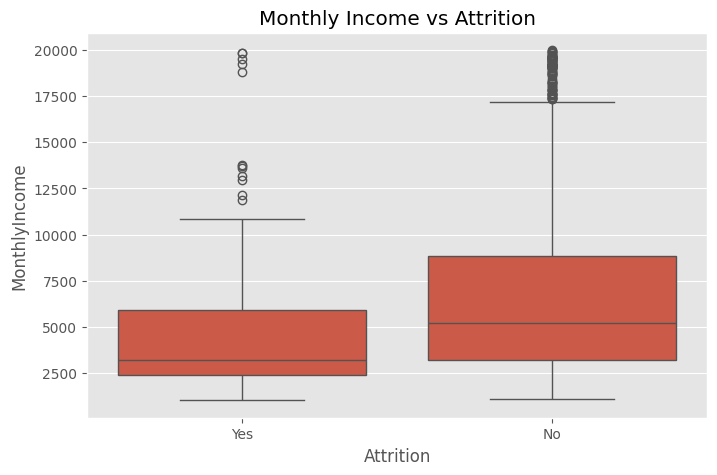

In [24]:
plt.figure(figsize=(8,5))
sns.boxplot(
    data=eda_df,
    x="Attrition",
    y="MonthlyIncome"
)
plt.title("Monthly Income vs Attrition")
plt.savefig("Income_Boxplot.png", dpi=300, bbox_inches="tight")
plt.show()

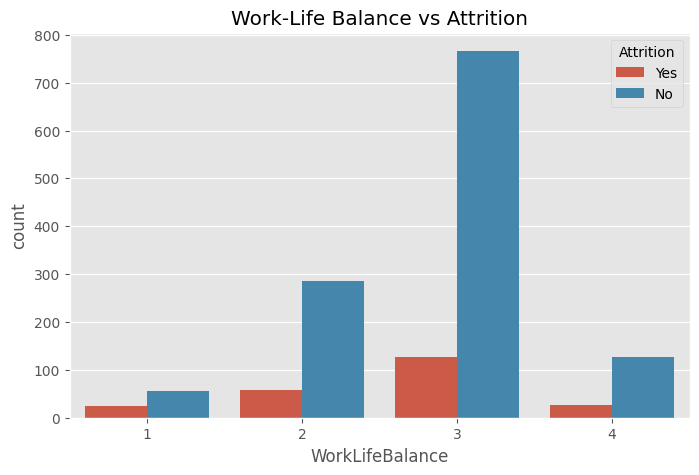

In [25]:
plt.figure(figsize=(8,5))
sns.countplot(
    data=eda_df,
    x="WorkLifeBalance",
    hue="Attrition"
)
plt.title("Work-Life Balance vs Attrition")
plt.savefig("WorkLifeBalance.png", dpi=300, bbox_inches="tight")
plt.show()

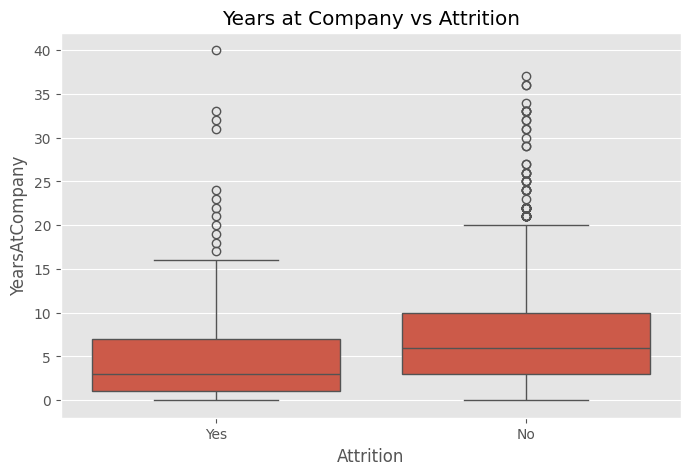

In [26]:
plt.figure(figsize=(8,5))
sns.boxplot(
    data=eda_df,
    x="Attrition",
    y="YearsAtCompany"
)
plt.title("Years at Company vs Attrition")
plt.savefig("YearsAtCompany.png", dpi=300, bbox_inches="tight")
plt.show()

# Employee Attrition Prediction using Machine Learning
### Name: Janvi Pawar
### Internship Week 2

# Task 1: Data Loading and Exploration

### Observation

The dataset contains 1,470 employee records. The target variable is **Attrition**, which indicates whether an employee left the company.

The attrition rate is around **16%**, which means most employees stayed with the company. Therefore, the dataset is **imbalanced**, since employees who stayed greatly outnumber employees who left.

# Task 2: Data Cleaning and Preprocessing

### Data Preprocessing Summary

- Checked for missing values (no missing values found).
- Removed unnecessary columns such as EmployeeNumber, EmployeeCount, Over18 and StandardHours.
- Converted the Attrition column from Yes/No to 1/0.
- Applied One-Hot Encoding to categorical variables.
- Standardized the features using StandardScaler.

# Task 3: Exploratory Data Analysis (EDA)

## Business Insights

1. The Sales department has the highest employee attrition compared to other departments.

2. Laboratory Technicians and Sales Executives show higher attrition than many other job roles.

3. Employees with lower monthly income tend to leave the company more often.

4. Employees having poor work-life balance are more likely to leave.

5. Most employees who leave the company have worked for fewer years, indicating higher attrition during the early stages of employment.

# Task 4: Model Building and Comparison

In [27]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training Data:", X_train.shape)
print("Testing Data:", X_test.shape)

Training Data: (1176, 44)
Testing Data: (294, 44)


In [28]:
lr = LogisticRegression(
    class_weight='balanced',
    random_state=42,
    max_iter=1000
)
lr.fit(X_train, y_train)
print("Logistic Regression Model Trained Successfully!")

Logistic Regression Model Trained Successfully!


In [29]:
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    class_weight='balanced'
)
rf.fit(X_train, y_train)
print("Random Forest Model Trained Successfully!")

Random Forest Model Trained Successfully!


In [30]:
gb = GradientBoostingClassifier(
    random_state=42
)
gb.fit(X_train, y_train)
print("Gradient Boosting Model Trained Successfully!")

Gradient Boosting Model Trained Successfully!


In [31]:
lr_pred = lr.predict(X_test)
rf_pred = rf.predict(X_test)
gb_pred = gb.predict(X_test)

In [32]:
print("========== Logistic Regression ==========")
print(classification_report(y_test, lr_pred))

========== Logistic Regression ==========
              precision    recall  f1-score   support

           0       0.91      0.77      0.84       247
           1       0.34      0.62      0.44        47

    accuracy                           0.75       294
   macro avg       0.63      0.70      0.64       294
weighted avg       0.82      0.75      0.77       294



In [33]:
print("========== Random Forest ==========")
print(classification_report(y_test, rf_pred))

========== Random Forest ==========
              precision    recall  f1-score   support

           0       0.85      0.98      0.91       247
           1       0.38      0.06      0.11        47

    accuracy                           0.83       294
   macro avg       0.61      0.52      0.51       294
weighted avg       0.77      0.83      0.78       294



In [34]:
print("========== Gradient Boosting ==========")
print(classification_report(y_test, gb_pred))

========== Gradient Boosting ==========
              precision    recall  f1-score   support

           0       0.87      0.97      0.92       247
           1       0.59      0.21      0.31        47

    accuracy                           0.85       294
   macro avg       0.73      0.59      0.61       294
weighted avg       0.82      0.85      0.82       294



In [35]:
lr_auc = roc_auc_score(y_test, lr.predict_proba(X_test)[:,1])

rf_auc = roc_auc_score(y_test, rf.predict_proba(X_test)[:,1])

gb_auc = roc_auc_score(y_test, gb.predict_proba(X_test)[:,1])

print("Logistic Regression ROC-AUC :", round(lr_auc,3))
print("Random Forest ROC-AUC :", round(rf_auc,3))
print("Gradient Boosting ROC-AUC :", round(gb_auc,3))

Logistic Regression ROC-AUC : 0.799
Random Forest ROC-AUC : 0.752
Gradient Boosting ROC-AUC : 0.794


In [36]:
comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "Gradient Boosting"
    ],
    "ROC-AUC Score": [
        lr_auc,
        rf_auc,
        gb_auc
    ]
})

comparison.sort_values(by="ROC-AUC Score", ascending=False)

,Model,ROC-AUC Score
0,Logistic Regression,0.798605
2,Gradient Boosting,0.794125
1,Random Forest,0.751917


### Model Comparison

Three machine learning models were trained and evaluated.

The model with the highest ROC-AUC score will be selected as the best model for predicting employee attrition.

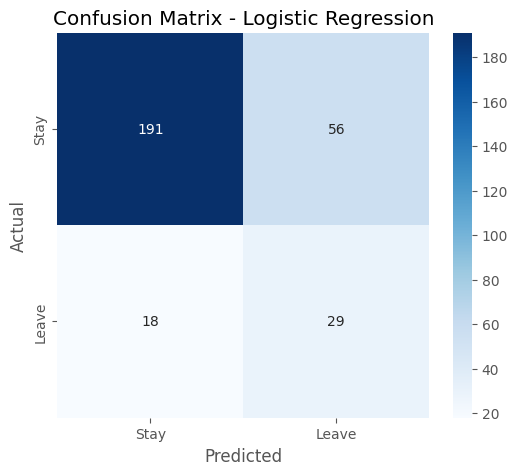

In [37]:
cm = confusion_matrix(y_test, lr_pred)
plt.figure(figsize=(6,5))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Stay', 'Leave'],
    yticklabels=['Stay', 'Leave']
)
plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.savefig("Confusion_Matrix.png", dpi=300, bbox_inches="tight")
plt.show()

In [38]:
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': abs(lr.coef_[0])
})

importance = importance.sort_values(by='Importance', ascending=False)

importance.head(10)

,Feature,Importance
34,JobRole_Laboratory Technician,0.797874
43,OverTime_Yes,0.766412
23,BusinessTravel_Travel_Frequently,0.719335
7,JobLevel,0.659189
16,TotalWorkingYears,0.656931
40,JobRole_Sales Representative,0.552515
24,BusinessTravel_Travel_Rarely,0.511649
27,EducationField_Life Sciences,0.506505
21,YearsSinceLastPromotion,0.500389
26,Department_Sales,0.481690


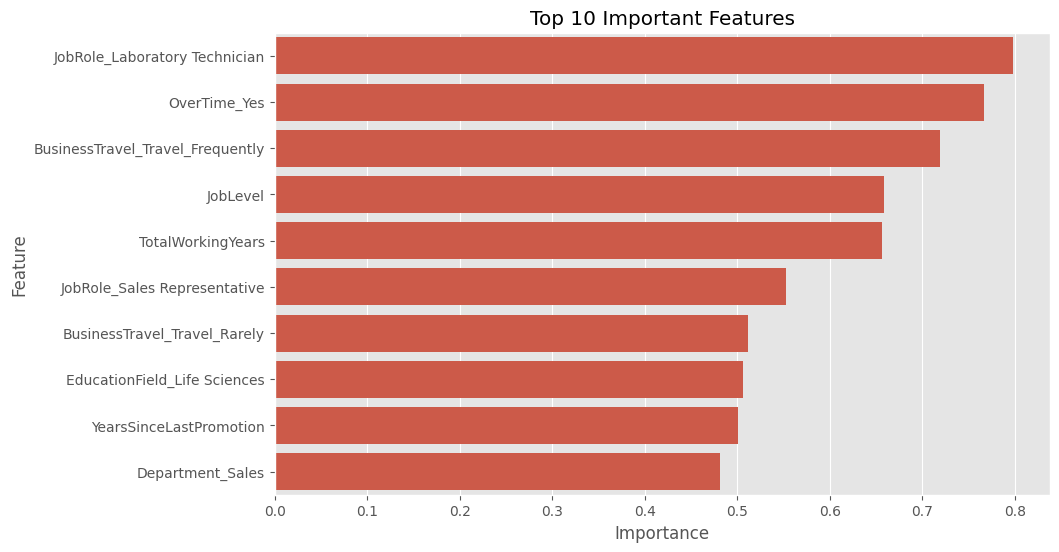

In [39]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=importance.head(10),
    x='Importance',
    y='Feature'
)
plt.title("Top 10 Important Features")
plt.savefig("Top10_Features.png", dpi=300, bbox_inches="tight")
plt.show()

### Best Model

Logistic Regression was selected as the best model because it achieved the highest ROC-AUC score among all three models.

The confusion matrix shows how accurately the model classified employees who stayed and those who left.

The feature importance analysis highlights the factors that have the strongest influence on employee attrition.

### Top 10 Important Features

The feature importance analysis indicates that the following factors have the strongest influence on employee attrition:

- Job Role (Laboratory Technician)
- Overtime
- Frequent Business Travel
- Job Level
- Total Working Years
- Job Role (Sales Representative)
- Business Travel (Travel Rarely)
- Education Field (Life Sciences)
- Years Since Last Promotion
- Department (Sales)

These features contribute the most to predicting whether an employee is likely to leave the organization.

In [40]:
plt.savefig("Top10_Features.png")

<Figure size 640x480 with 0 Axes>

In [41]:
import os
os.makedirs("charts", exist_ok=True)

In [42]:
plt.savefig("charts/Top10_Features.png", dpi=300, bbox_inches="tight")

<Figure size 640x480 with 0 Axes>

In [43]:
import shutil
import os

os.makedirs("charts", exist_ok=True)

files = [
    "Department_Attrition.png",
    "JobRole_Attrition.png",
    "Income_Boxplot.png",
    "WorkLifeBalance.png",
    "YearsAtCompany.png",
    "Confusion_Matrix.png",
    "Top10_Features.png"
]

for file in files:
    if os.path.exists(file):
        shutil.move(file, f"charts/{file}")

print("All available charts moved to the charts folder!")

All available charts moved to the charts folder!


# Task 6: Model Evaluation Visualizations

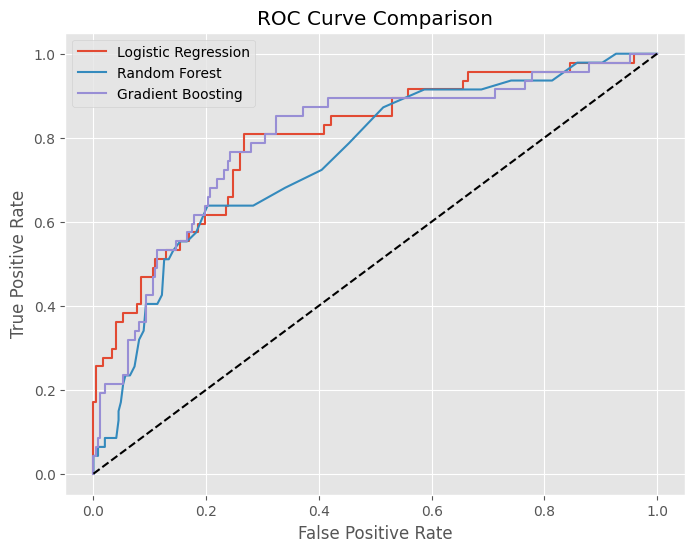

In [44]:
from sklearn.metrics import roc_curve

plt.figure(figsize=(8,6))

# Logistic Regression
fpr_lr, tpr_lr, _ = roc_curve(y_test, lr.predict_proba(X_test)[:,1])
plt.plot(fpr_lr, tpr_lr, label='Logistic Regression')

# Random Forest
fpr_rf, tpr_rf, _ = roc_curve(y_test, rf.predict_proba(X_test)[:,1])
plt.plot(fpr_rf, tpr_rf, label='Random Forest')

# Gradient Boosting
fpr_gb, tpr_gb, _ = roc_curve(y_test, gb.predict_proba(X_test)[:,1])
plt.plot(fpr_gb, tpr_gb, label='Gradient Boosting')

plt.plot([0,1],[0,1],'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()

plt.savefig("charts/ROC_Curve.png", dpi=300, bbox_inches="tight")

plt.show()

# Task 7: HR Insights & Business Recommendations

## Which 3 factors most strongly predict employee attrition?

The analysis indicates that overtime, job role (especially Laboratory Technician and Sales Representative), and frequent business travel are the strongest predictors of employee attrition.

## Which department or job role should HR prioritize?

The Sales department and Laboratory Technicians should be prioritized for employee retention initiatives because they exhibit higher attrition levels than other groups.

## Does salary alone explain attrition?

No. Although monthly income influences attrition, other factors such as overtime, job role, work-life balance, and business travel have a greater impact on predicting whether an employee will leave.

## HR Recommendations

1. Conduct regular retention discussions with employees who frequently work overtime or travel for business.

2. Improve work-life balance through flexible work policies, career development opportunities, and timely promotions, especially for employees in high-risk job roles.

## Limitation

This model is based on historical employee data and may not capture future organizational changes or personal reasons behind employee resignations. Therefore, HR should use the predictions as a decision-support tool rather than the sole basis for making decisions.

# Conclusion

This project successfully developed a machine learning model to predict employee attrition using HR analytics data.

Among the three models evaluated, Logistic Regression achieved the highest ROC-AUC score and was selected as the best-performing model. The analysis identified overtime, job role, business travel, and total working years as major factors influencing employee attrition.

These insights can help HR teams identify employees at higher risk of leaving and take proactive measures to improve employee retention.